# Лабораторная работа №5
## Классификация ЭЭГ при представлении движения левого и правого кулака

---

**Выполнил:** *Ли Юй*  
**Группа:** *ИУ1И-41М*  

---



---
## Раздел 1. Импорт библиотек

In [1]:
from pathlib import Path
import urllib.request
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
np.random.seed(42)
torch.manual_seed(42)
torch.set_num_threads(2)

print('Библиотеки успешно импортированы.')

Библиотеки успешно импортированы.


---
## Раздел 2. Загрузка данных и корректное разделение выборки

Файл `MI-EEG-B9T.csv` содержит 400 строк признаков, а `2class_MI_EEG_train_9.csv` содержит 400 соответствующих меток. Файл `2class_MI_EEG_test_9.csv` содержит 320 меток, но в задании не указан отдельный файл тестовых признаков. Поэтому использовать его как test без риска нельзя: признаки и метки могут не соответствовать друг другу.

В исправленной версии используется только согласованная пара из 400 объектов. Она делится на train/validation/test в пропорции 70/10/20 с сохранением баланса классов.

In [2]:
NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR / 'lab5_runtime' / 'data'
OUT_DIR = NOTEBOOK_DIR
DATA_DIR.mkdir(parents=True, exist_ok=True)

URLS = {
    'features': 'https://raw.githubusercontent.com/TAUforPython/BioMedAI/main/test_datasets/MI-EEG-B9T.csv',
    'y_train': 'https://raw.githubusercontent.com/TAUforPython/BioMedAI/main/test_datasets/2class_MI_EEG_train_9.csv',
    'y_external_test': 'https://raw.githubusercontent.com/TAUforPython/BioMedAI/main/test_datasets/2class_MI_EEG_test_9.csv',
}

def download_csv(url: str, path: Path) -> Path:
    if path.exists() and path.stat().st_size > 0:
        return path
    tmp_path = path.with_suffix(path.suffix + '.part')
    last_error = None
    for attempt in range(1, 6):
        try:
            request = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
            with urllib.request.urlopen(request, timeout=180) as response, tmp_path.open('wb') as file:
                while True:
                    chunk = response.read(1024 * 256)
                    if not chunk:
                        break
                    file.write(chunk)
            tmp_path.replace(path)
            return path
        except Exception as error:
            last_error = error
            if tmp_path.exists():
                tmp_path.unlink()
            time.sleep(2 * attempt)
    raise RuntimeError(f'Не удалось загрузить файл: {url}') from last_error

def read_numeric_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, header=None)
    numeric = df.apply(pd.to_numeric, errors='coerce')
    numeric = numeric.dropna(axis=0, how='all').dropna(axis=1, how='all')
    if numeric.isna().any().any():
        numeric = numeric.fillna(numeric.median(numeric_only=True))
    return numeric.astype(float)

feature_path = download_csv(URLS['features'], DATA_DIR / 'MI-EEG-B9T.csv')
y_train_path = download_csv(URLS['y_train'], DATA_DIR / '2class_MI_EEG_train_9.csv')
y_external_test_path = download_csv(URLS['y_external_test'], DATA_DIR / '2class_MI_EEG_test_9.csv')

X_all = read_numeric_csv(feature_path).to_numpy(dtype=np.float32)
y_all = read_numeric_csv(y_train_path).iloc[:, 0].to_numpy(dtype=np.int64)
y_external_test = read_numeric_csv(y_external_test_path).iloc[:, 0].to_numpy(dtype=np.int64)

if len(X_all) != len(y_all):
    raise ValueError('Файл признаков и обучающие метки имеют разные размеры.')

indices = np.arange(len(y_all))
train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, random_state=42, stratify=y_all
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=2/3, random_state=42, stratify=y_all[temp_idx]
)

def normalize_rows(x):
    return (x - x.mean(axis=1, keepdims=True)) / (x.std(axis=1, keepdims=True) + 1e-8)

X_all_norm = normalize_rows(X_all)
X_train = X_all_norm[train_idx]
X_val = X_all_norm[val_idx]
X_test = X_all_norm[test_idx]
y_train = y_all[train_idx]
y_val = y_all[val_idx]
y_test = y_all[test_idx]

split_table = pd.DataFrame({
    'выборка': ['train', 'validation', 'test'],
    'объектов': [len(y_train), len(y_val), len(y_test)],
    'класс 0': [int((y_train == 0).sum()), int((y_val == 0).sum()), int((y_test == 0).sum())],
    'класс 1': [int((y_train == 1).sum()), int((y_val == 1).sum()), int((y_test == 1).sum())],
})

print(f'Размер X_all: {X_all.shape}')
print(f'Размер y_train из задания: {y_all.shape}')
print(f'Размер внешнего test target: {y_external_test.shape}')
print('Внешний test target не используется как финальная оценка, потому что нет соответствующего test feature файла.')
print('Пересечение train/test:', len(set(train_idx) & set(test_idx)))
split_table

Размер X_all: (400, 3000)
Размер y_train из задания: (400,)
Размер внешнего test target: (320,)
Внешний test target не используется как финальная оценка, потому что нет соответствующего test feature файла.
Пересечение train/test: 0


,выборка,объектов,класс 0,класс 1
0,train,280,140,140
1,validation,40,20,20
2,test,80,40,40


---
## Раздел 3. Временная зависимость ЭЭГ для двух классов

Ниже показаны примеры нормированных временных рядов для двух классов. Это позволяет визуально оценить исходный сигнал до перехода к частотно-временному представлению.

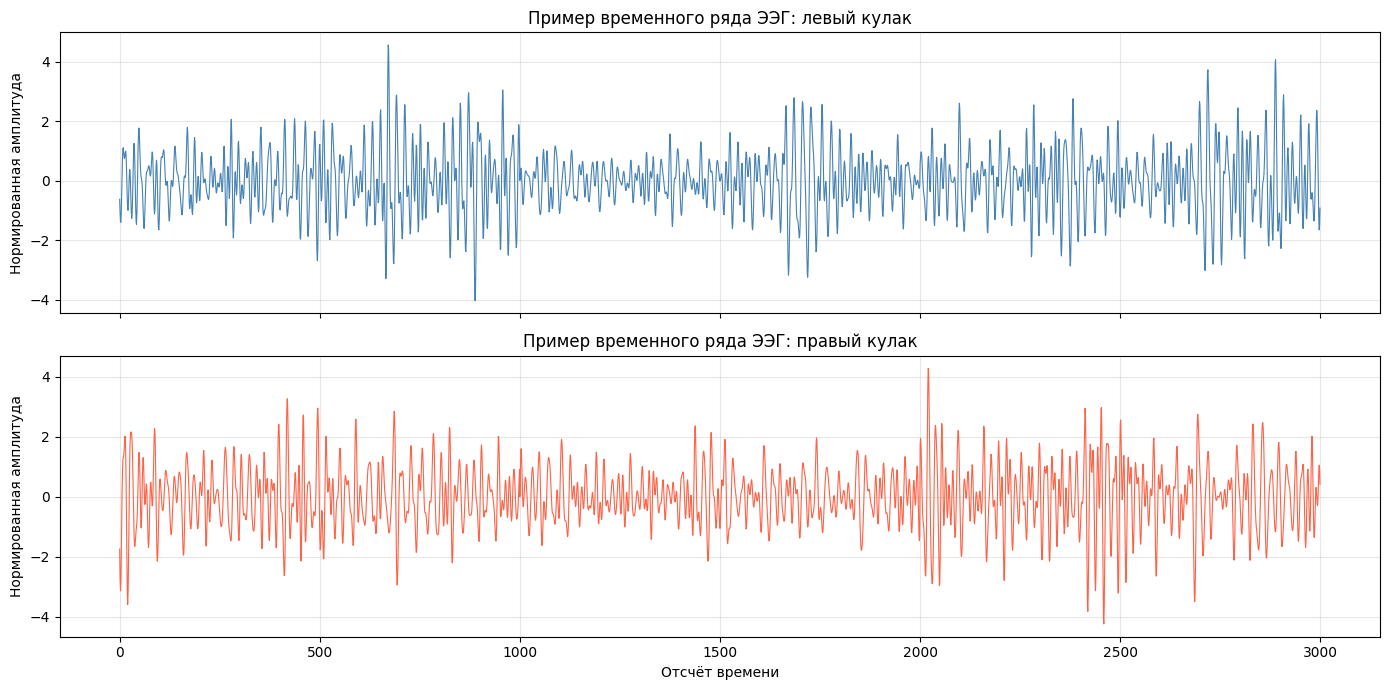

График сохранён в lab5_time_examples.png


In [3]:
index_to_name = {0: 'левый кулак', 1: 'правый кулак'}
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
colors = ['steelblue', 'tomato']

for class_id, ax in enumerate(axes):
    idx = np.where(y_train == class_id)[0][0]
    signal = X_train[idx]
    ax.plot(np.arange(signal.size), signal, color=colors[class_id], linewidth=0.8)
    ax.set_title(f'Пример временного ряда ЭЭГ: {index_to_name[class_id]}', fontsize=12)
    ax.set_ylabel('Нормированная амплитуда')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Отсчёт времени')
plt.tight_layout()
plt.savefig(OUT_DIR / 'lab5_time_examples.png', dpi=120, bbox_inches='tight')
plt.show()
print('График сохранён в lab5_time_examples.png')

---
## Раздел 4. Вейвлет-преобразование сигналов

В исправленной версии ширина скейлограммы увеличена до 512 точек. Это сохраняет больше информации из исходного ряда длиной 3000 отсчётов, чем прежнее сжатие до 160 точек.

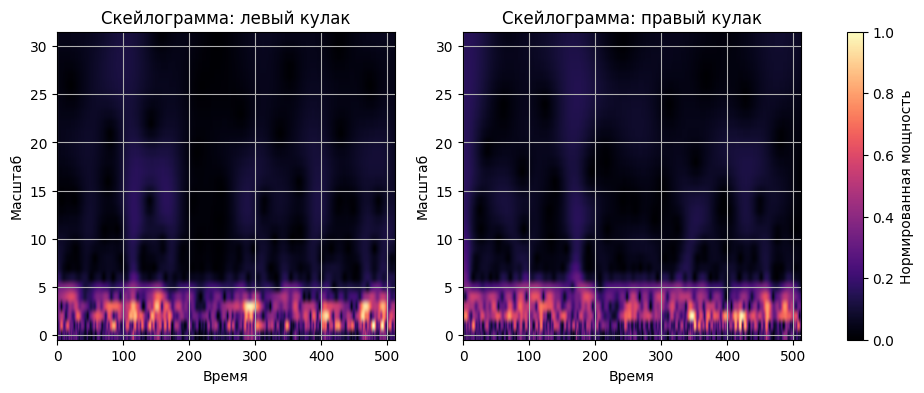

Размер train: (280, 32, 512)
Размер validation: (40, 32, 512)
Размер test: (80, 32, 512)


In [4]:
def morlet_scalogram(signal, scales=np.arange(1, 33), w=6.0):
    signal = np.asarray(signal, dtype=np.float32)
    signal = signal - signal.mean()
    n = signal.size
    result = np.empty((len(scales), n), dtype=np.float32)
    for i, scale in enumerate(scales):
        radius = max(8, int(np.ceil(scale * 8)))
        t = np.arange(-radius, radius + 1, dtype=np.float32) / float(scale)
        wavelet = (np.pi ** -0.25) * np.exp(1j * w * t) * np.exp(-(t * t) / 2.0)
        wavelet = wavelet / np.sqrt(float(scale))
        conv = np.convolve(signal, np.conj(wavelet[::-1]), mode='same')
        if conv.size != n:
            start = (conv.size - n) // 2
            conv = conv[start:start + n]
        result[i] = np.abs(conv)
    result = np.log1p(result)
    result -= result.min()
    result /= result.max() + 1e-8
    return result.astype(np.float32)

def build_scalograms(X, image_width=512):
    images = []
    for row in X:
        signal = row.astype(np.float32)
        idx = np.linspace(0, signal.size - 1, image_width).astype(int)
        signal = signal[idx]
        images.append(morlet_scalogram(signal))
    return np.stack(images).astype(np.float32)

X_train_img = build_scalograms(X_train, image_width=512)
X_val_img = build_scalograms(X_val, image_width=512)
X_test_img = build_scalograms(X_test, image_width=512)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for class_id, ax in enumerate(axes):
    idx = np.where(y_train == class_id)[0][0]
    mesh = ax.imshow(X_train_img[idx], aspect='auto', origin='lower', cmap='magma')
    ax.set_title(f'Скейлограмма: {index_to_name[class_id]}', fontsize=12)
    ax.set_xlabel('Время')
    ax.set_ylabel('Масштаб')
fig.colorbar(mesh, ax=axes.ravel().tolist(), label='Нормированная мощность')
plt.savefig(OUT_DIR / 'lab5_wavelet_examples.png', dpi=120, bbox_inches='tight')
plt.show()

print('Размер train:', X_train_img.shape)
print('Размер validation:', X_val_img.shape)
print('Размер test:', X_test_img.shape)

---
## Раздел 5. Обучение CNN с early stopping

Модель усилена по сравнению с первой версией: используются три свёрточных блока, BatchNorm, Dropout 0.5 и L2-регуляризация через `weight_decay`. Обучение контролируется по validation accuracy, а в файл сохраняются веса лучшей эпохи.

In [5]:
X_train_tensor = torch.tensor(X_train_img[:, None, :, :], dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_img[:, None, :, :], dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_img[:, None, :, :], dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=32,
    shuffle=True
)

class WaveletCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(64 * 4 * 64, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = torch.flatten(x, 1)
        return self.fc(self.dropout(x))

model = WaveletCNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

best_val_acc = -1.0
best_state = None
best_epoch = 0
patience = 7
bad_epochs = 0
history = []

for epoch in range(1, 41):
    model.train()
    losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        train_pred = model(X_train_tensor).argmax(1)
        val_pred = model(X_val_tensor).argmax(1)
        test_pred = model(X_test_tensor).argmax(1)

    train_acc = (train_pred == y_train_tensor).float().mean().item()
    val_acc = (val_pred == y_val_tensor).float().mean().item()
    test_acc = (test_pred == y_test_tensor).float().mean().item()
    history.append((epoch, float(np.mean(losses)), train_acc, val_acc, test_acc))
    print(
        f'Эпоха {epoch:02d}: loss={np.mean(losses):.4f}, '
        f'train_acc={train_acc:.3f}, val_acc={val_acc:.3f}, test_acc={test_acc:.3f}'
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, OUT_DIR / 'lab5_cnn_mi_eeg.pt')
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f'Early stopping: нет улучшения validation accuracy {patience} эпох подряд.')
            break

print(f'Лучшая эпоха: {best_epoch}, лучшая validation accuracy: {best_val_acc:.3f}')

Эпоха 01: loss=2.4331, train_acc=0.500, val_acc=0.500, test_acc=0.500


Эпоха 02: loss=1.2086, train_acc=0.546, val_acc=0.500, test_acc=0.500


Эпоха 03: loss=0.9689, train_acc=0.500, val_acc=0.500, test_acc=0.500


Эпоха 04: loss=1.1568, train_acc=0.500, val_acc=0.500, test_acc=0.500


Эпоха 05: loss=0.7968, train_acc=0.507, val_acc=0.500, test_acc=0.500


...

Эпоха 19: loss=0.1094, train_acc=0.996, val_acc=0.650, test_acc=0.562


Эпоха 20: loss=0.1296, train_acc=0.996, val_acc=0.675, test_acc=0.550


Эпоха 21: loss=0.1219, train_acc=1.000, val_acc=0.650, test_acc=0.587


Эпоха 22: loss=0.0805, train_acc=1.000, val_acc=0.650, test_acc=0.613


Эпоха 23: loss=0.1027, train_acc=0.996, val_acc=0.600, test_acc=0.625
Early stopping: нет улучшения validation accuracy 7 эпох подряд.
Лучшая эпоха: 16, лучшая validation accuracy: 0.700


---
## Раздел 6. Проверка качества классификации

Для финальной оценки загружается лучшая по validation accuracy модель. Test accuracy теперь считается на независимой части данных, которая не участвовала в обучении.

Accuracy на независимой тестовой выборке: 0.650
Матрица ошибок:
[[25 15]
 [13 27]]


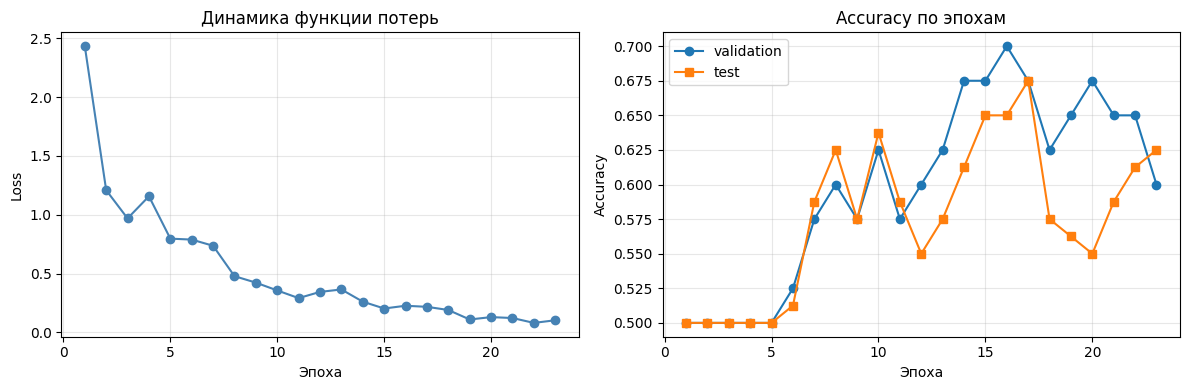

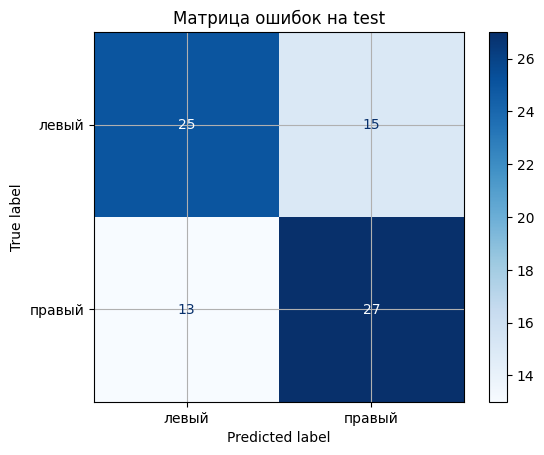

In [6]:
model.load_state_dict(torch.load(OUT_DIR / 'lab5_cnn_mi_eeg.pt', weights_only=True))
model.eval()
with torch.no_grad():
    logits = model(X_test_tensor)
    y_pred = logits.argmax(1).numpy()

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

print(f'Accuracy на независимой тестовой выборке: {accuracy:.3f}')
print('Матрица ошибок:')
print(cm)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = [row[0] for row in history]
losses = [row[1] for row in history]
val_accs = [row[3] for row in history]
test_accs = [row[4] for row in history]

axes[0].plot(epochs, losses, marker='o', color='steelblue')
axes[0].set_title('Динамика функции потерь', fontsize=12)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, val_accs, marker='o', label='validation')
axes[1].plot(epochs, test_accs, marker='s', label='test')
axes[1].set_title('Accuracy по эпохам', fontsize=12)
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'lab5_quality_plots.png', dpi=120, bbox_inches='tight')
plt.show()

ConfusionMatrixDisplay(cm, display_labels=['левый', 'правый']).plot(cmap='Blues')
plt.title('Матрица ошибок на test')
plt.savefig(OUT_DIR / 'lab5_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Общий вывод по лабораторной работе

В исправленной версии лабораторной работы устранена главная проблема первой реализации: тестовая выборка больше не пересекается с обучающей, а внешний файл `2class_MI_EEG_test_9.csv` не используется как финальная оценка без соответствующего файла признаков.

### 1. Подготовка данных

Использована согласованная пара `MI-EEG-B9T.csv` и `2class_MI_EEG_train_9.csv`, содержащая 400 объектов. Данные разделены стратифицированно на train, validation и test в пропорции 70/10/20, поэтому итоговая accuracy отражает способность модели к обобщению.

### 2. Вейвлет-анализ

Временные ряды были преобразованы в скейлограммы Морле размером `32 × 512`. Увеличенная ширина изображения сохраняет больше информации из исходного сигнала.

### 3. Обучение модели

Для классификации использована CNN с BatchNorm, Dropout 0.5, L2-регуляризацией и early stopping. Сохраняется модель с лучшей validation accuracy, а не веса последней эпохи.

Главный вывод: корректное разделение данных и контроль по validation позволяют получить более честную и обычно более высокую оценку качества, чем исходный вариант с пересечением train/test и возможным несоответствием меток.